# Day 4 — CLT, Correlation

## Bicocca Lectures 3 and 4



In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad

rng = np.random.default_rng(42)

print("Python executable:")
print(sys.executable)
print("\nNotebook working great! Welcome back.")

Python executable:
C:\Users\krist\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe

Notebook working great! Welcome back.


# Monte Carlo Integration

Here is a geometric version that shows how monte carlo integration is done. We estimate an area or integral by random sampling.

First we choose a region whose size is already known (here it is 4) and generate random points uniformly inside it.
At each point, we evaluate the function and average the results. 
Multiplying the average by the size of the region gives an estimate of the integral.

Estimate of pi: 3.16


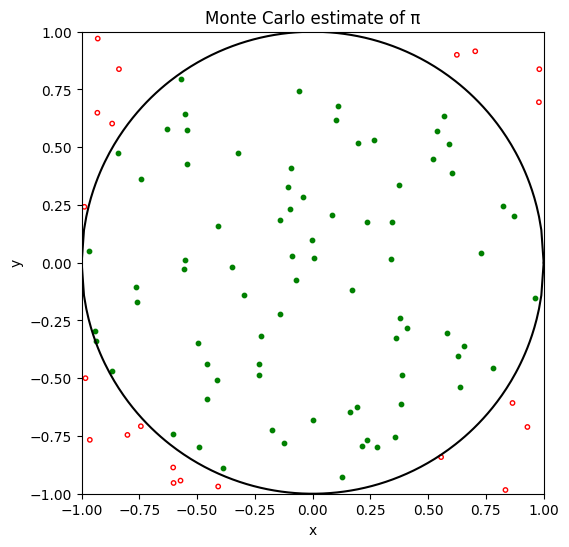

In [3]:
n = 100
x = np.random.uniform(-1, 1, n)
y = np.random.uniform(-1, 1, n)

inside = x**2 + y**2 <= 1
m = np.sum(inside)

# Plot inside and outside points
fig, ax = plt.subplots(figsize=(6, 6))

plt.scatter(x[inside],
            y[inside],
            s=10,
            c="green",
            marker="o",
            label="Inside"
)

plt.scatter(
    x[~inside],
    y[~inside],
    s=10,
    facecolors="none",
    edgecolors="red",
    marker="o",
    label="Outside"
)

# Draw the unit circle
xx = np.linspace(-1, 1, 200)

ax.plot(xx, np.sqrt(1 - xx**2), c="black")
ax.plot(xx, -np.sqrt(1 - xx**2), c="black")

ax.set(
    title="Monte Carlo estimate of π",
    xlabel="x",
    ylabel="y",
    xlim=(-1, 1),
    ylim=(-1, 1),
    aspect="equal"
)

print("Estimate of pi:", 4 * m / n)


Say you have a complicated integral to solve, but you can write down the integrand as a product of $f(x)$ and $p(x)$

\begin{equation}
I = \int f(x) p(x) \, dx

\end{equation}

where p(x) is the probability density satisfying: 
\begin{equation}
\int p(x) dx = 1
\end{equation}

As long as you can evaluate f(x) and sample p(x), then

\begin{equation}

\int f(x) p(x) dx \approx \frac{1}{N} \sum^N _ {i = 1} f(x_i)

\end{equation}

## Example

Say we try to solve:

$$
I=\int_0^2 e^{-x^2}\,dx
$$

$$
I=(2-0)\,\mathbb{E}\left[e^{-X^2}\right], \qquad X\sim\operatorname{Uniform}(0,2)
$$

$$
I\approx
\frac{2}{N}\sum_{i=1}^{N}e^{-x_i^2}
$$

In [4]:
#integration limits + size of sample
xmin = 0.0
xmax = 2.0
n = 100_000


def f(x):
    #Function being integrated here
    return np.exp(-x**2)


# Uniform sample from the interval
x_samples = rng.uniform(xmin, xmax, size=n)

# Evaluate the function at every sampled point
function_values = f(x_samples)

# Monte Carlo estimate:
# interval width × average function height
width = xmax - xmin
mc_estimate = width * np.mean(function_values)

# Estimated Monte Carlo standard error
mc_error = width * np.std(function_values, ddof=1) / np.sqrt(n)

# Accurate numerical result for comparison
quad_result, quad_error = quad(f, xmin, xmax)

print(f"Monte Carlo estimate: {mc_estimate:.6f}")
print(f"Monte Carlo error:    {mc_error:.6f}")
print(f"Scipy quad result:    {quad_result:.6f}")
print(f"Difference between the values:  {abs(mc_estimate - quad_result):.6f}")

Monte Carlo estimate: 0.880204
Monte Carlo error:    0.002179
Scipy quad result:    0.882081
Difference between the values:  0.001877


## Descriptive Statistics and Distributions

Lecture 3 (Bicocca) next returns to descriptive statistics and common distributions. I already covered these in much more detail on Days 2 and 3, so there is no need to repeat all of the lecture plots here.

The useful ideas to were:

- **location:** mean and median
- **scale:** standard deviation, IQR and median absolute deviation
- **shape:** skewness and kurtosis
- a SciPy distribution object can generate random values and evaluate a PDF, PMF or CDF

I will demonstrate these ideas briefly using the SDSS redshift data and one Gaussian distribution.

### SDSS Redshift Summary

This is a short check using the data I have been. The median, IQR and median absolute deviation are less sensitive to extreme values than the mean and standard deviation.

mean                         0.110951
median                       0.103996
standard deviation           0.054505
IQR                          0.072356
median absolute deviation    0.035630
skewness                     0.817849
excess kurtosis              1.110715
dtype: float64

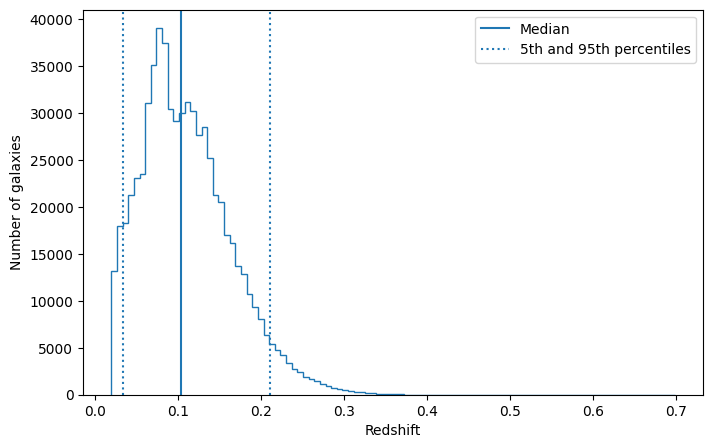

In [5]:
from astroML.datasets import fetch_sdss_specgals

galaxies = fetch_sdss_specgals()
z = np.asarray(galaxies["z"], dtype=float)
z = z[np.isfinite(z)]

median = np.median(z)
q5, q25, q75, q95 = np.percentile(z, [5, 25, 75, 95])
mad = np.median(np.abs(z - median))

summary = pd.Series({
    "mean": np.mean(z),
    "median": median,
    "standard deviation": np.std(z, ddof=1),
    "IQR": q75 - q25,
    "median absolute deviation": mad,
    "skewness": stats.skew(z, bias=False),
    "excess kurtosis": stats.kurtosis(z, fisher=True, bias=False),
})

display(summary)

plt.figure(figsize=(8, 5))
plt.hist(z, bins=100, histtype="step")
plt.axvline(median, label="Median")
plt.axvline(q5, linestyle=":", label="5th and 95th percentiles")
plt.axvline(q95, linestyle=":")
plt.xlabel("Redshift")
plt.ylabel("Number of galaxies")
plt.legend()
plt.show()

### The Useful `scipy.stats` Pattern

For most named distributions, the important methods are:

- `.rvs()` to generate random values
- `.pdf()` for a continuous probability density
- `.pmf()` for a discrete probability mass
- `.cdf()` for cumulative probability


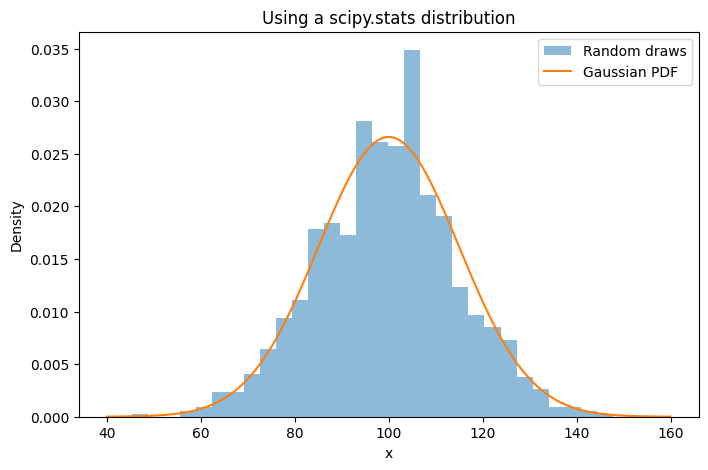

P(mu - 2 sigma < X < mu + 4 sigma): 0.9772181968099877


In [4]:
normal = stats.norm(loc=100, scale=15)

draws = normal.rvs(size=1000, random_state=rng)
x = np.linspace(40, 160, 500)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(draws, bins=30, density=True, alpha=0.5, label="Random draws")
ax.plot(x, normal.pdf(x), label="Gaussian PDF")
ax.set(xlabel="x", ylabel="Density", title="Using a scipy.stats distribution")
ax.legend()
plt.show()

probability = normal.cdf(100 + 4 * 15) - normal.cdf(100 - 2 * 15)
print("P(mu - 2 sigma < X < mu + 4 sigma):", probability)

## Importance Sampling

Sometimes it is hard to sample directly from the part of the function that contributes most to the integral.

Instead, you sample values from a probability distribution $p(x)$ that is easier to use:

\begin{equation}
I=\int_0^\infty f(x)\,dx
\end{equation}

You multiply and divide by p(x):

\begin{equation}
I=\int_0^\infty \frac{f(x)}{p(x)}p(x)\,dx
\end{equation}

This means you can sample $x_i$ from $p(x)$, and give each sample a weight

\begin{equation}
w_i=\frac{f(x_i)}{p(x_i)}
\end{equation}

The integral is then estimated by taking the mean of these weights:

\begin{equation}
I\approx\frac{1}{N}\sum_{i=1}^{N}w_i
\end{equation}

Here, I use an exponential distribution for $p(x)$.

Tbf i sometimes struggle to follow what its saying so I hope this is pretty accurate

In [7]:
#integration limits + size of sample
xmin = 0.0
xmax = 99999999.0
n = 1_000_000
sigma = 0.111
lam = 1/sigma

def f(x):
    #Function being integrated here
    return x**3*np.exp(-x**2/ (2*sigma**2))


# Sample from the exponential proposal
x_samp = rng.exponential(scale = 1/ lam, size=n)
p = lam* np.exp(-lam*x_samp)

weights = f(x_samp) / p


# Monte Carlo estimate:
mc_estimate = np.mean(weights)

# Estimated Monte Carlo standard error
mc_error =  np.std(weights, ddof=1) / np.sqrt(n)

# Accurate numerical result for comparison
Exact = 2*sigma**4

print(f"Monte Carlo estimate: {mc_estimate:.6f}")
print(f"Monte Carlo error:    {mc_error:.6f}")
print(f"Exact:    {Exact:.6f}")
print(f"Difference between the values:  {abs(mc_estimate - Exact):.6f}")

Monte Carlo estimate: 0.000304
Monte Carlo error:    0.000000
Exact:    0.000304
Difference between the values:  0.000001


## Here we will look at the Central Limit Theorem with code

For an arbitrary distribution, $h(x)$, with a well defined mean, $\mu$ and standard deviation, $\sigma$ (This means the tails fall off faster than $1/x^2$), the mean of N values {x_i} drawn from the distribution will follow a Gaussian distribution with $N(\mu,\sigma/\sqrt{N})$


So looking at $h(x) = N(0.5,1/\sqrt{12})$. Using the Central Limit theorem we can get the distribution of the mean to follow $N(o.5, 1/\sqrt{12}/\sqrt{N})$

The below code is from the Bicocca_2026 lecture

In [8]:
import numpy as np
import os
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats
from tqdm.notebook import tqdm
plt.rcParams['figure.figsize'] = [6, 6]

Text(0, 0.5, 'pdf')

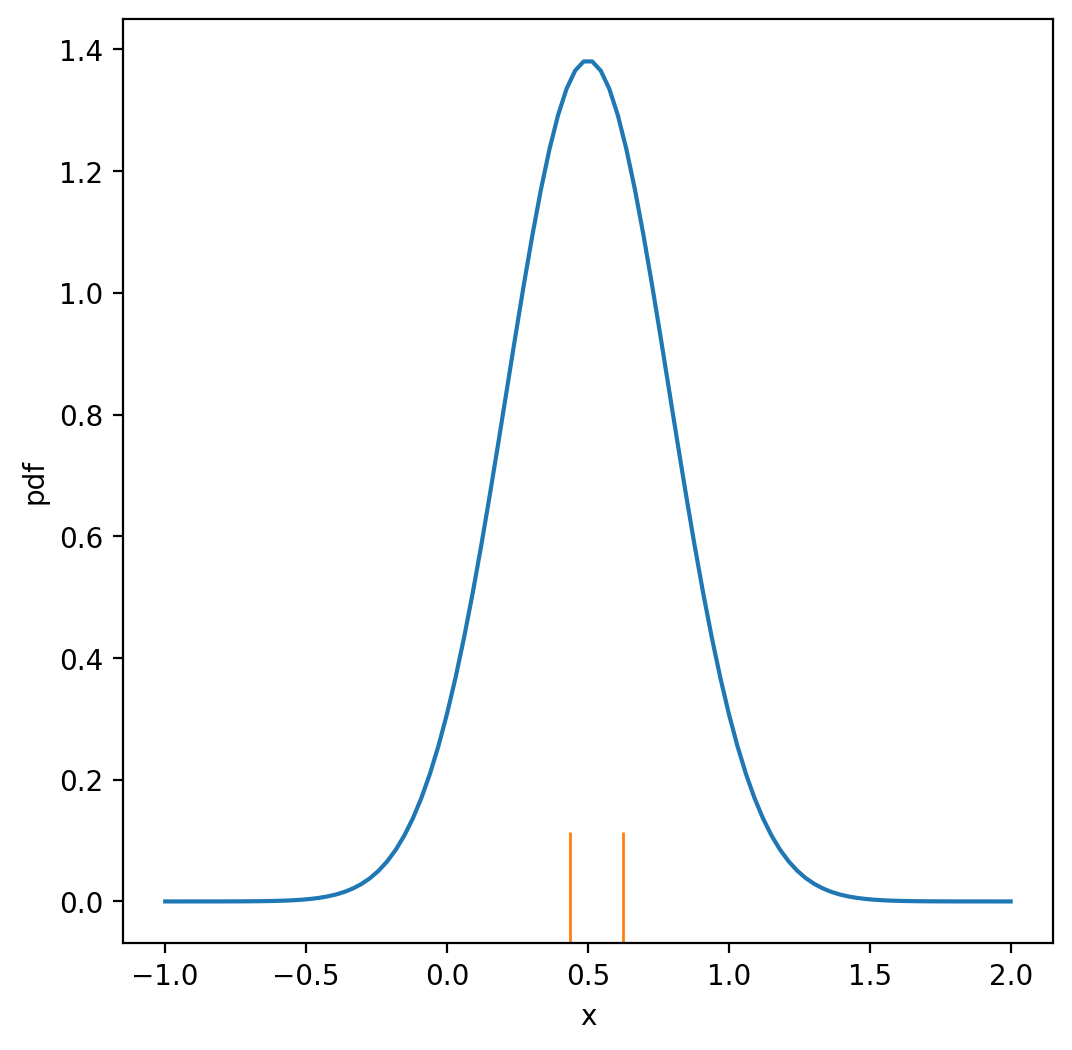

In [9]:
N = 2 # Number of draws
mu = 0.5 # Location
sigma_h = 1.0 / np.sqrt(12) # scale of h(x)

xgrid = np.linspace(-1,2,100)  
distG = scipy.stats.norm(loc=mu, scale=sigma_h) #scale is the std
plt.plot(xgrid, distG.pdf(xgrid))

x = np.random.normal(mu, sigma_h,2) # Two random draws
plt.plot(x, 0*x, '|', markersize=50) #marks the 2 random draws
plt.xlabel('x')
plt.ylabel('pdf')

So this code is taking $N=2$ measurements and plotting them and the one after

  0%|          | 0/10000 [00:00<?, ?it/s]

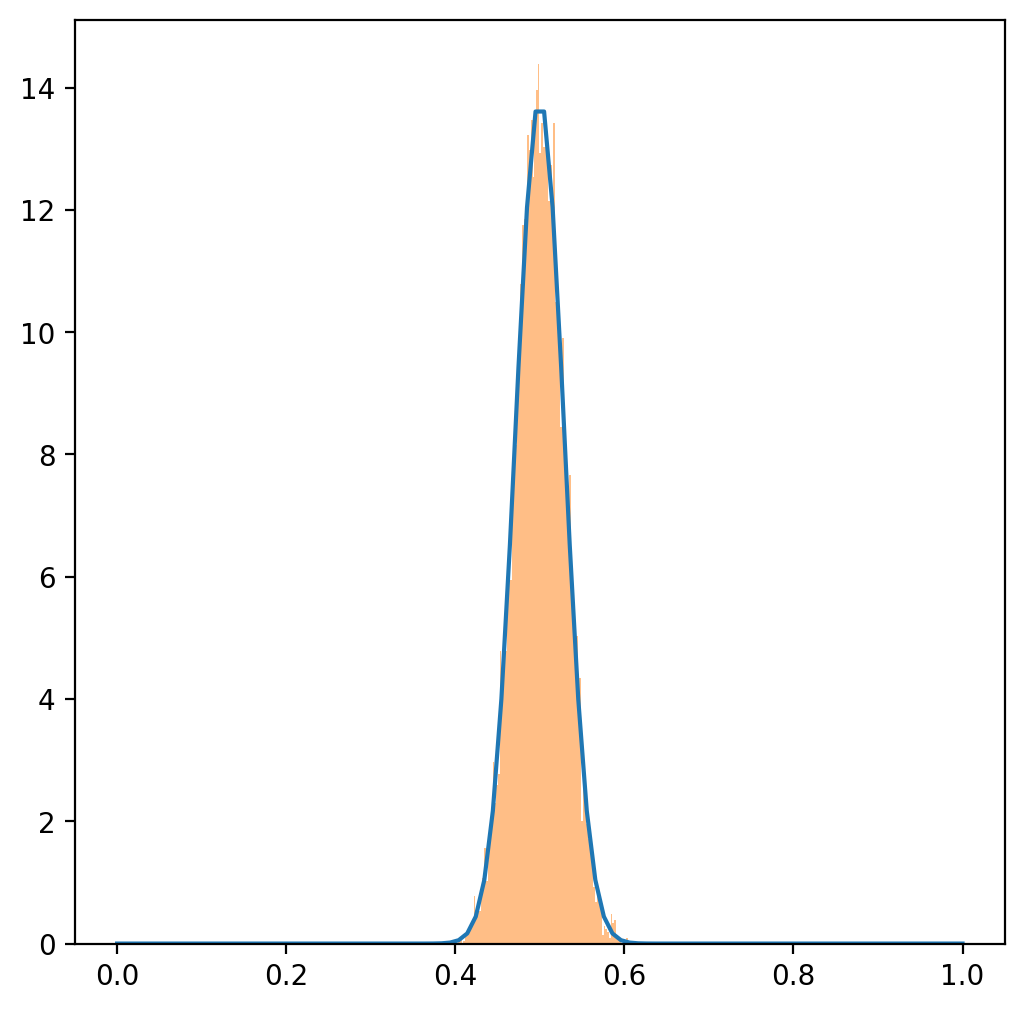

In [10]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm

N = 100 # Number of draws

xmin=0
xmax=1
mu = 0.5 # Location
sigma_h = 1.0 / np.sqrt(12) # scale of h(x)
sigma_cl = sigma_h / np.sqrt(N) # scale of mean error distribution
xgrid = np.linspace(0,1,100)  

# plot the distribution of means according to central limit theorem
distG = scipy.stats.norm(mu, sigma_cl) # Complete
plt.plot(xgrid, distG.pdf(xgrid)) # Complete
# Add a histogram that is the mean of 100,000 batches of N draws
yy = []
for i in tqdm(np.arange(10000)):
    xx = np.random.normal(loc=mu, scale=sigma_h, size=N) # N random draws
    yy.append(np.average(xx)) # Append average of those random draws to the end of the array

plt.hist(yy, bins=100, histtype='stepfilled', alpha=0.5, density=True);

Tried to recreate it with memory.

To note, the second sigma is used for the spread of the batch means, whereas the initial sigma is used for the spread of the individual observations

  0%|          | 0/10000 [00:00<?, ?it/s]

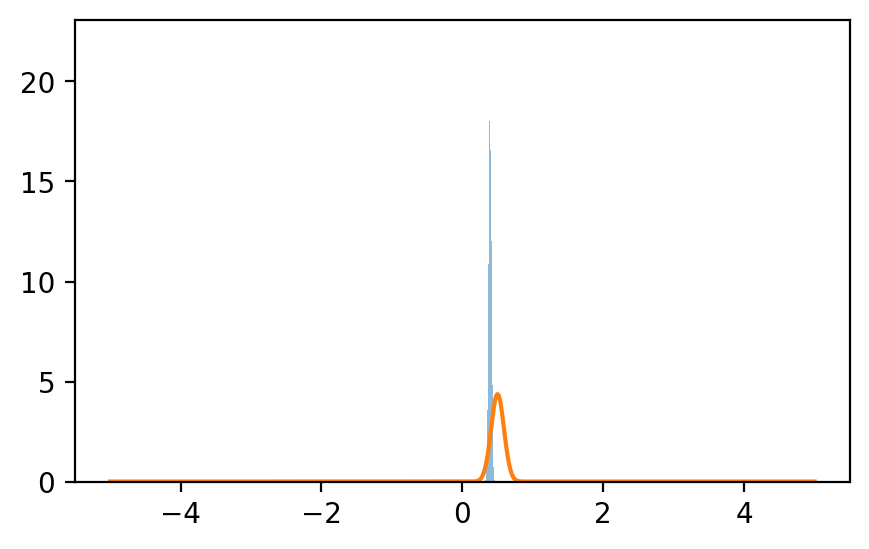

In [ ]:
x = np.linspace(-5,5,1000)
N = 10
mean = 0.5
sigma = 1 / np.sqrt(12)
sigma_c_1 = sigma / np.sqrt(N)

distG = scipy.stats.norm(mean,sigma_c_1)

yy = []

for i in tqdm(np.arange(10000)):
    xx = np.random.normal(mean, sigma, size=N)
    yy.append(np.average(xx))


plt.figure(figsize= (5,3))
plt.hist(yy, bins = 100, alpha = 0.5, density = True)
plt.plot(x,distG.pdf(x))

## Bivariate and Multivariate pdfs

### Bivariate prob distributions

This part was quite tricky to follow as I was up late, but this is what I have learnt from it.

A joint probability density function, $h(x,y)$ describes the probability density of observing a combination of two variables.

It must satisfy 

$$
\int^\infty_{-\infty}\int^\infty_{-\infty} h(x,y) dxdy = 1
$$

If we wish to obtain the distribution of x or y alone. We need to marginalise over every possible value of the other variable. E.g

$$
h(x) = \int^\infty_{-\infty}h(x,y)dy
$$

So marginalising means removing a variable we do not care about by integrating over all its possible values.

### Mean, variance and covariance

Each two dimension distribution has a mean and variance for each dimension.

$$
\mu_x = E(x), \qquad \mu_y = E(y), \qquad \sigma_x^2 = Var(X)...
$$

The covariance is 

$$
\sigma_{xy} = Cov(X,Y) = E[(X-\mu_x)(Y-\mu_y)]
$$

The sign of this expression tells us how the variables move, for example, if $\sigma_{xy} > 0$. Mean that larger X tend to follow larger Y.

### bivariate Gaussian

A bivariate Gaussian describes two quantities that are jointly distributed. E.g galaxy colour and luminosity or stellar mass and metallicity.

The probability density forms a bell shaped surface over an xy plane, this is similar to mountains on a map. Equal density contours form ellipses.

The full distribution (gulp):

$$p(x,y)=\frac{1}{2\pi\sigma_x\sigma_y\sqrt{1-\rho^2}}\exp\left[-\frac{z^2}{2(1-\rho^2)}\right]$$


where (another gulp):

$$z^2=\frac{(x-\mu_x)^2}{\sigma_x^2}+\frac{(y-\mu_y)^2}{\sigma_y^2}-2\rho\frac{(x-\mu_x)(y-\mu_y)}{\sigma_x\sigma_y}$$

Now we have to assess what each parameter within these equations means.

1. $\mu_x, \mu_y$ locate the centre of the cloud
2. $\sigma_x, \sigma_y$ controls the spread in its respective direction
3. $\rho$ controls the strength and direction of the linear relationship

What does z^2 measure?

Well it measured how statistically unusual a point is relative to the centre. If there is no correlation, the third term vanishes so its the sum of two squared standardised distances.

### Correlation coefficient

The population correlation coefficient is the covariance divided by the two standard deviations

$$
\rho = \frac{\sigma_{xy}}{\sigma_x \sigma_y}
$$

And sigma is between 1 and -1.

The way we can conceptualise this is that 

1. $\rho> 0$: larger x tends to accompany larger y
2. $\rho < 0$ larger x tends to accompany smaller y
3. $\rho = 0$ There is no linear correlation

As $\rho \rightarrow 1$, the points become increasingly concentrated around a line

#### How can we interpret results then?

Equal density contours satisfy $h(x,y) = const$

Due to the fact that the exponent contains a quadratic, they form ellipses.

If there is no correlation and equal variance. The contours are circles

If they have no correlation and unequal variance. The contours are ellipses and aligned with the coordinate axis.

If there is correlation. The ellipse rotates, positive upwards, negative downwards.

### The principal axes

We can rotate the coordinate system through an angle $\alpha$ such that it lines up with the natural direction of the data

To rotate the coordinates you use the following equations

$$P_1=(x-\mu_x)\cos\alpha+(y-\mu_y)\sin\alpha, \qquad P_2=-(x-\mu_x)\sin\alpha+(y-\mu_y)\cos\alpha$$

Within these coordinates, the covariance of P_1 and P_2 is zero.

The variance then changes along the two directions as we are measuring from different points, we now measure the major axis (+ solution) and minor axis (- solution)

$$
\sigma_{1,2}^2=\frac{\sigma_x^2+\sigma_y^2}{2}\pm\sqrt{\left(\frac{\sigma_x^2-\sigma_y^2}{2}\right)^2+\sigma_{xy}^2}
$$

Once correlation becomes stronger, the major axis becomes longer, the minor axis becomes shorter and the ellipse hence tends to a thinner more like a line.
A fun fact that the total variance is preserved, $\sigma_{\mathrm{major}}^2+\sigma_{\mathrm{minor}}^2=\sigma_x^2+\sigma_y^2$.

This is as the new rotation doesn't create extra scatter, it just formats it into the two natural directions.

### Estimating the bivariate Gaussian

When we have actual data, we need to estimate the centre, spread and covariance of the distribution from the sample.

For the centre we use the sample means

$$
\bar{x}=\frac{1}{N}\sum_{i=1}^{N}x_i, \qquad \bar{y}=\frac{1}{N}\sum_{i=1}^{N}y_i
$$

We can then estimate the variance in each direction using

$$
s_x^2=\frac{1}{N-1}\sum_{i=1}^{N}(x_i-\bar{x})^2
$$

and

$$
s_y^2=\frac{1}{N-1}\sum_{i=1}^{N}(y_i-\bar{y})^2
$$

The sample covariance is then

$$
s_{xy}=\frac{1}{N-1}\sum_{i=1}^{N}(x_i-\bar{x})(y_i-\bar{y})
$$

We can put all of this information inside a covariance matrix

$$
C=
\begin{pmatrix}
s_x^2 & s_{xy}\\
s_{xy} & s_y^2
\end{pmatrix}
$$

The values on the diagonal are the variance of each variable, while the values off the diagonal are the covariance between the variables.

One issue with this is that the mean, variance and covariance can all be strongly affected by outliers.

An outlier can pull the centre of the distribution towards itself, increase the variance and change the covariance. This means that the ellipse can stretch and rotate towards the outlier, even if the outlier does not represent the main population.

This is because variance uses squared distances and covariance multiplies the two distances from the mean.

For example, an outlier in the upper right would have

$$
x_i-\bar{x}>0, \qquad y_i-\bar{y}>0
$$

Therefore its contribution to the covariance would be

$$
(x_i-\bar{x})(y_i-\bar{y})>0
$$

If both of these distances are very large, the outlier may contribute much more than the rest of the points.

We can instead use more robust estimators which are less sensitive to extreme values. For example, we may use the median to estimate the centre and a robust covariance estimator to estimate the shape of the distribution.

### Generalising to multiple dimensions

We can generalise the bivariate Gaussian into any number of dimensions.

Instead of having only $x$ and $y$, we can place all of our variables inside a vector

$$
\vec{x}=
\begin{pmatrix}
x_1\\
x_2\\
\vdots\\
x_M
\end{pmatrix}
$$

We can also place all of the means inside a mean vector

$$
\vec{\mu}=
\begin{pmatrix}
\mu_1\\
\mu_2\\
\vdots\\
\mu_M
\end{pmatrix}
$$

The covariance matrix then contains the variance and covariance of every variable

$$
C=E\left[(\vec{x}-\vec{\mu})(\vec{x}-\vec{\mu})^T\right]
$$

For three variables this would look like

$$
C=
\begin{pmatrix}
\sigma_1^2 & \sigma_{12} & \sigma_{13}\\
\sigma_{21} & \sigma_2^2 & \sigma_{23}\\
\sigma_{31} & \sigma_{32} & \sigma_3^2
\end{pmatrix}
$$

The variances are on the diagonal

$$
C_{ii}=Var(X_i)
$$

The covariances between different variables are off the diagonal

$$
C_{ij}=Cov(X_i,X_j)
$$

The covariance matrix is symmetric as

$$
C_{ij}=C_{ji}
$$

This is because the covariance of $X$ with $Y$ is the same as the covariance of $Y$ with $X$.

The full multivariate Gaussian is another evil equation

$$
p(\vec{x}\mid\vec{\mu},C)=\frac{1}{(2\pi)^{M/2}\sqrt{\det C}}\exp\left[-\frac{1}{2}(\vec{x}-\vec{\mu})^TC^{-1}(\vec{x}-\vec{\mu})\right]
$$

We can break this equation down into different parts.

1. $\vec{x}-\vec{\mu}$ measures how far the point is from the centre in every direction
2. $C^{-1}$ accounts for the variance and covariance between the variables
3. $\det C$ describes the overall size of the distribution
4. The exponential means points become less probable as they become more unusual

The expression

$$
D_M^2=(\vec{x}-\vec{\mu})^TC^{-1}(\vec{x}-\vec{\mu})
$$

is known as the squared Mahalanobis distance.

This measures how statistically unusual a point is, while accounting for the shape of the distribution.

A normal distance treats every direction in the same way. However, a Mahalanobis distance knows that the distribution may be wider in one direction than another.

For example, moving a long distance along the major axis may not be very unusual because the data naturally have a large spread in that direction.

Moving the same distance across the minor axis may be much more unusual because the distribution is narrow in that direction.

If there is no covariance then

$$
C=
\begin{pmatrix}
\sigma_x^2 & 0\\
0 & \sigma_y^2
\end{pmatrix}
$$

The inverse covariance matrix is then

$$
C^{-1}=
\begin{pmatrix}
\frac{1}{\sigma_x^2} & 0\\
0 & \frac{1}{\sigma_y^2}
\end{pmatrix}
$$

Therefore the Mahalanobis distance becomes

$$
D_M^2=
\frac{(x-\mu_x)^2}{\sigma_x^2}
+
\frac{(y-\mu_y)^2}{\sigma_y^2}
$$

This is just the sum of the squared standardised distances in each direction.

### Confidence levels in two dimensions

In one dimension, being within one standard deviation of the mean contains around $68\%$ of a Gaussian distribution.

However, this is different in two dimensions.

For a circular two dimensional Gaussian, the probability density depends on the radial distance from the centre

$$
r=\sqrt{x^2+y^2}
$$

The probability density is

$$
p(r)=\frac{1}{2\pi s^2}\exp\left[-\frac{1}{2}\left(\frac{r}{s}\right)^2\right]
$$

The probability contained inside a radius $R$ is

$$
P(r\leq R)=1-\exp\left[-\frac{1}{2}\left(\frac{R}{s}\right)^2\right]
$$

If we set the radius to one standard deviation

$$
R=s
$$

we obtain

$$
P(r\leq s)=1-\exp\left(-\frac{1}{2}\right)
$$

Therefore

$$
P(r\leq s)\approx0.393
$$

So a one sigma contour in two dimensions only contains around $39.3\%$ of the total probability.

This is different from the $68\%$ we normally remember from one dimension.

The reason is that probability is now spread across an area rather than just along a line.

A point can also be within one standard deviation in both variables but still be more than one standard deviation away from the centre radially.

For example, suppose

$$
x-\mu_x=0.8s, \qquad y-\mu_y=0.8s
$$

The radial distance would be

$$
r=\sqrt{(0.8s)^2+(0.8s)^2}
$$

Therefore

$$
r\approx1.13s
$$

So the point is within one standard deviation in both $x$ and $y$, but it is outside the one sigma circle.

If we want the contour to contain $68\%$ of the probability, we need to solve

$$
0.68=1-\exp\left[-\frac{1}{2}\left(\frac{R}{s}\right)^2\right]
$$

This gives approximately

$$
R\approx1.51s
$$

Therefore a contour containing $68\%$ of the probability in two dimensions has a radius of around $1.51$ standard deviations.

This is important when we interpret corner plots, as a one sigma radius and a contour containing $68\%$ of the samples are not the same thing.

### Correlation coefficients

We now want a single number which tells us how strongly two variables are related.

We should remember that correlation does not mean causation.

Two variables may be correlated because one causes the other, but they may also both depend on a third hidden variable.

### Pearsons correlation coefficient

Pearsons coefficient measures the strength and direction of a linear relationship between two variables.

It is defined as

$$
r=
\frac{
\sum_{i=1}^{N}(x_i-\bar{x})(y_i-\bar{y})
}{
\sqrt{\sum_{i=1}^{N}(x_i-\bar{x})^2}
\sqrt{\sum_{i=1}^{N}(y_i-\bar{y})^2}
}
$$

This is effectively the covariance divided by the spread of the two variables

$$
r=\frac{s_{xy}}{s_xs_y}
$$

The numerator looks at whether $x$ and $y$ move away from their means in the same direction.

For a point in the upper right

$$
x_i-\bar{x}>0, \qquad y_i-\bar{y}>0
$$

Therefore

$$
(x_i-\bar{x})(y_i-\bar{y})>0
$$

So this point contributes positively towards the correlation.

For a point in the lower left

$$
x_i-\bar{x}<0, \qquad y_i-\bar{y}<0
$$

The product is also positive because multiplying two negative numbers gives a positive result.

For a point in the lower right

$$
x_i-\bar{x}>0, \qquad y_i-\bar{y}<0
$$

Therefore

$$
(x_i-\bar{x})(y_i-\bar{y})<0
$$

So this point contributes negatively towards the correlation.

Pearsons coefficient satisfies

$$
-1\leq r\leq1
$$

The way we can interpret this is

1. $r\approx1$: There is a strong positive linear relationship
2. $r\approx-1$: There is a strong negative linear relationship
3. $r\approx0$: There is little or no linear relationship

It is important that $r\approx0$ only means there is no linear relationship.

There may still be a strong non linear relationship between the variables.

For example, if

$$
y=x^2
$$

the variables are clearly related, but the Pearson coefficient may be close to zero if the data are symmetric around zero.

#### Testing whether the correlation is significant

A sample may have a non zero value of $r$ even if the true population is uncorrelated.

The null hypothesis is

$$
H_0:\rho=0
$$

We can transform the measured value of $r$ into

$$
t=r\sqrt{\frac{N-2}{1-r^2}}
$$

Under the null hypothesis, this follows a Students $t$ distribution with

$$
N-2
$$

degrees of freedom.

This allows us to calculate how unusual our measured correlation would be if the true population correlation was zero.

The size of the sample is important.

A large correlation found from only a few points may happen by chance. The same correlation found from thousands of points would be much less likely to happen by chance.

The value of $r$ and the $p$ value therefore tell us different things.

1. $r$ tells us the strength and direction of the relationship
2. The $p$ value tells us how unusual the result would be under the null hypothesis

There are two important problems with Pearsons coefficient.

1. It does not include measurement uncertainties
2. It is very sensitive to outliers

Pearsons coefficient uses the actual numerical distances from the mean.

Therefore, one very distant point can have a very large effect on both the numerator and denominator.

### Spearmans correlation coefficient

Spearmans coefficient is similar to Pearsons coefficient, but it replaces the actual values with their ranks.

The smallest value is given rank $1$ and the largest value is given rank $N$.

For example, if

$$
x=[10,30,20,50]
$$

we first place the values in order

$$
10<20<30<50
$$

The ranks in the original order are then

$$
R^x=[1,3,2,4]
$$

Spearmans coefficient is

$$
r_S=
\frac{
\sum_{i=1}^{N}(R_i^x-\overline{R^x})(R_i^y-\overline{R^y})
}{
\sqrt{\sum_{i=1}^{N}(R_i^x-\overline{R^x})^2}
\sqrt{\sum_{i=1}^{N}(R_i^y-\overline{R^y})^2}
}
$$

This is just Pearsons coefficient applied to the ranks rather than the original values.

Pearsons coefficient measures a linear relationship, while Spearmans coefficient measures a monotonic relationship.

A monotonic relationship means that one variable consistently increases or consistently decreases as the other variable increases.

The relationship does not have to be a straight line.


Spearmans coefficient is also less sensitive to outliers.

For example, an extreme value of $1000$ and an extreme value of $1000000$ would both simply receive the largest rank.


Spearmans coefficient can still be affected if the outlier changes the ordering, but its actual distance from the rest of the data is less important.

The significance test can be approximated using

$$
t=r_S\sqrt{\frac{N-2}{1-r_S^2}}
$$

with N-2 degrees of freedom.

### Kendalls correlation coefficient

Kendalls coefficient also uses the ordering of the data, but it compares every possible pair of observations.

Suppose we take two observations $j$ and $k$.

A pair is concordant if the ordering agrees in both variables

$$
(x_j-x_k)(y_j-y_k)>0
$$

For example, if

$$
x_j>x_k, \qquad y_j>y_k
$$

then observation $j$ is larger in both variables, so the pair is concordant.

The pair is also concordant if

$$
x_j<x_k, \qquad y_j<y_k
$$

as the ordering still agrees in both variables.

A pair is discordant if the ordering goes in opposite directions

$$
(x_j-x_k)(y_j-y_k)<0
$$

For example, if

$$
x_j>x_k, \qquad y_j<y_k
$$

then observation $j$ is larger in $x$ but smaller in $y$, so the pair is discordant.

The total number of different pairs is

$$
\frac{N(N-1)}{2}
$$

If $N_c$ is the number of concordant pairs and $N_d$ is the number of discordant pairs, Kendalls coefficient is

$$
\tau=2\frac{N_c-N_d}{N(N-1)}
$$

This can also be written as

$$
\tau=\frac{N_c-N_d}{N(N-1)/2}
$$

So Kendalls coefficient is the number of concordant pairs minus the number of discordant pairs, divided by the total number of pairs.

The way we can interpret this is

1. $\tau=1$: Every pair is concordant
2. $\tau=-1$: Every pair is discordant
3. $\tau\approx0$: There are around the same number of concordant and discordant pairs

For example, suppose there are six pairs in total.

If five are concordant and one is discordant then

$$
N_c=5, \qquad N_d=1
$$

Therefore

$$
\tau=\frac{5-1}{6}
$$

which gives

$$
\tau=\frac{2}{3}
$$

This is positive because most of the pairs preserve the same ordering.

Kendalls coefficient has quite a nice intuitive meaning.

It asks whether knowing which observation has a larger $x$ value normally tells us which observation has a larger $y$ value.


## Resources

- [Bicocca 2026 — L03 Probability and Statistics II](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/lectures/L03_probability.ipynb)
- [Bicocca 2026 - L04](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/lectures/L04_probability.ipynb) 
- _Statistics, Data Mining and Machine Learning in Astronomy_, Chapter 3
- Day 2 notebook for descriptive statistics
- Day 3 notebook for common distributions and the Central Limit Theorem